In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.calibration import CalibrationDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree





In [2]:
X_train = pd.read_csv("X_train.csv", index_col=0)
X_test  = pd.read_csv("X_test.csv", index_col=0)
y_train = pd.read_csv("y_train.csv", index_col=0).iloc[:,0]
y_test  = pd.read_csv("y_test.csv", index_col=0).iloc[:,0]

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((609, 32),
 (153, 32),
 DESERTA
 0    527
 1     82
 Name: count, dtype: int64,
 DESERTA
 0    133
 1     20
 Name: count, dtype: int64)

In [7]:
# Fuerza categóricas a string para OHE robusto
X_train = X_train.apply(lambda s: s.astype(str))
X_test  = X_test.apply(lambda s: s.astype(str))

cat_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop"
)

In [8]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_pipe = Pipeline([("prep", preprocessor), ("clf", dt)])
dt_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
proba = dt_pipe.predict_proba(X_test)[:,1]
pred  = (proba >= 0.5).astype(int)
print(f"ROC AUC : {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba):.3f}")
print(classification_report(y_test, pred, digits=3, target_names=["No deserta (0)","Deserta (1)"]))
cm = confusion_matrix(y_test, pred, labels=[0,1])
display(pd.DataFrame(cm, index=["Real 0","Real 1"], columns=["Pred 0","Pred 1"]))

ROC AUC : 0.591
PR-AUC  : 0.187
                precision    recall  f1-score   support

No deserta (0)      0.892     0.932     0.912       133
   Deserta (1)      0.357     0.250     0.294        20

      accuracy                          0.843       153
     macro avg      0.625     0.591     0.603       153
  weighted avg      0.822     0.843     0.831       153



,Pred 0,Pred 1
Real 0,124,9
Real 1,15,5


In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "clf__max_depth": [3, 4, 6, 8, None],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__min_samples_split": [10, 20, 40],
    "clf__max_features": [None, "sqrt", 0.3],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    dt_pipe, param_grid,
    scoring="average_precision",  # mejor en desbalance
    cv=cv, n_jobs=-1, refit=True, verbose=0
)
grid.fit(X_train, y_train)
dt_best = grid.best_estimator_
print("Mejores params:", grid.best_params_)

# Test
proba = dt_best.predict_proba(X_test)[:,1]
print(f"PR-AUC (test): {average_precision_score(y_test, proba):.3f}")


Mejores params: {'clf__max_depth': 4, 'clf__max_features': None, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 40}
PR-AUC (test): 0.556


In [14]:

proba_dt = dt_best.predict_proba(X_test)[:,1]   # usa tu mejor árbol
prec, rec, thr = precision_recall_curve(y_test, proba_dt)
thr = np.r_[0.0, thr]
f1 = 2*prec*rec / np.where(prec+rec==0, np.inf, prec+rec)
i = int(np.nanargmax(f1)); thr_f1 = float(thr[i])

pred_f1 = (proba_dt >= thr_f1).astype(int)
print(f"Umbral F1* = {thr_f1:.3f} | P={prec[i]:.3f} R={rec[i]:.3f} F1={f1[i]:.3f}")
print(classification_report(y_test, pred_f1, digits=3,
                            target_names=["No deserta (0)","Deserta (1)"]))

cm = confusion_matrix(y_test, pred_f1, labels=[0,1])
display(pd.DataFrame(cm, index=["Real 0","Real 1"], columns=["Pred 0","Pred 1"]))

Umbral F1* = 0.741 | P=0.733 R=0.550 F1=0.629
                precision    recall  f1-score   support

No deserta (0)      0.940     0.940     0.940       133
   Deserta (1)      0.600     0.600     0.600        20

      accuracy                          0.895       153
     macro avg      0.770     0.770     0.770       153
  weighted avg      0.895     0.895     0.895       153



,Pred 0,Pred 1
Real 0,125,8
Real 1,8,12


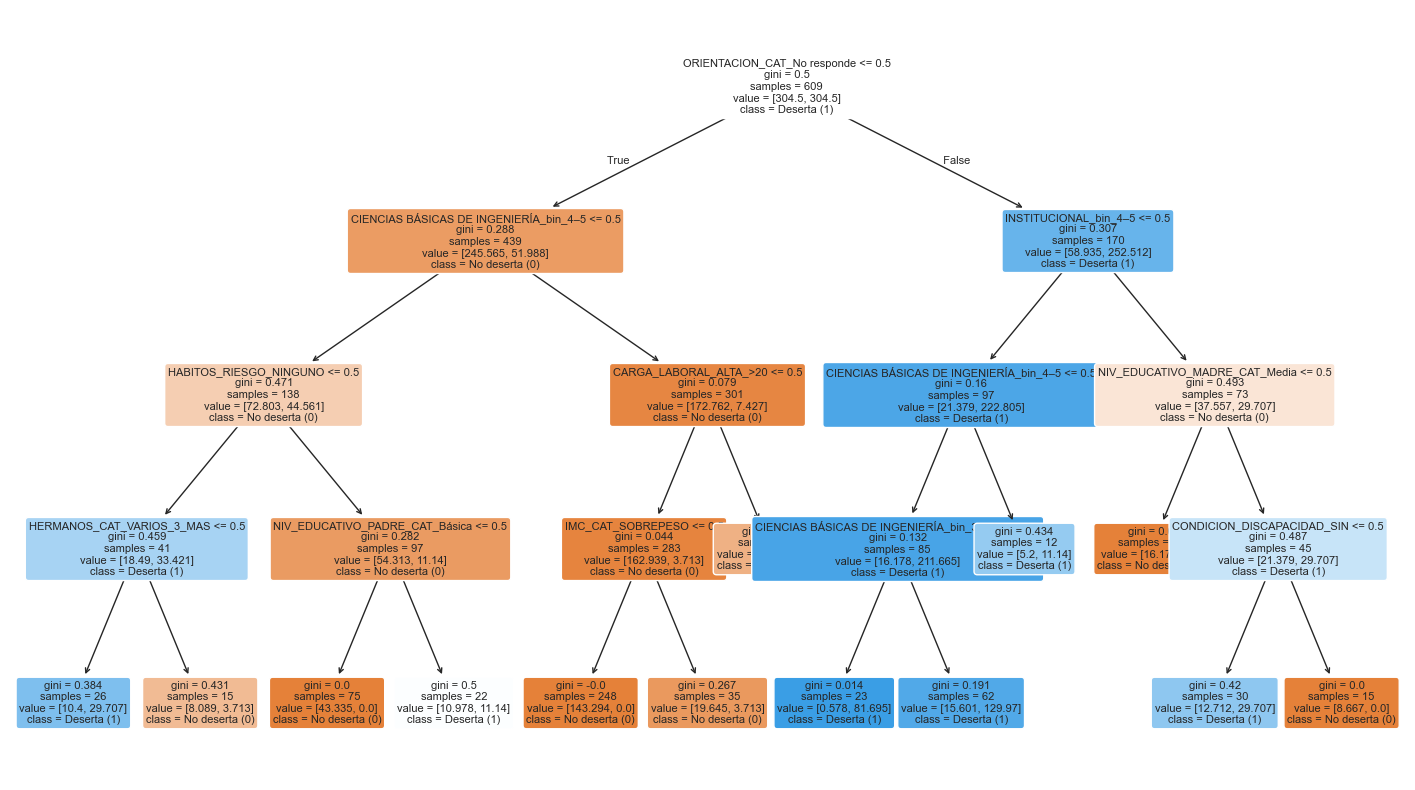

In [15]:
# nombres tras OHE
ohe = dt_best.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feat_names = ohe.get_feature_names_out(X_train.columns)

plt.figure(figsize=(18,10))
tree.plot_tree(
    dt_best.named_steps["clf"],
    feature_names=feat_names,
    class_names=["No deserta (0)","Deserta (1)"],
    filled=True, rounded=True, max_depth=4, fontsize=8
)
plt.show()

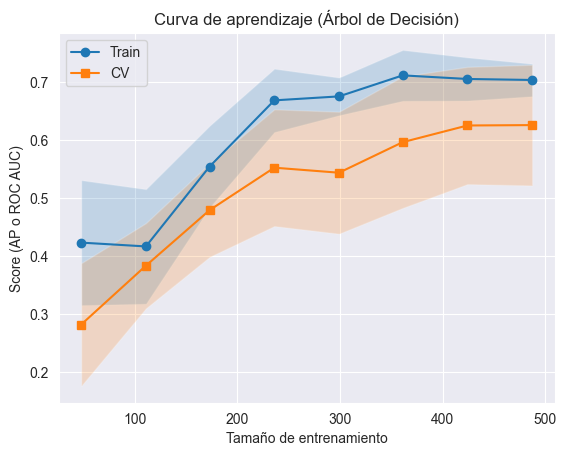

In [16]:
model = dt_best       # árbol afinado por GridSearch
# model = dt_pruned   # si hiciste poda con ccp_alpha

# Conjunto de entrenamiento
X, y = X_train, y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

sizes, tr, va = learning_curve(
    estimator=model,
    X=X, y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring="average_precision",   # o "roc_auc" si prefieres
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

tr_m, tr_s = tr.mean(axis=1), tr.std(axis=1)
va_m, va_s = va.mean(axis=1), va.std(axis=1)

plt.figure()
plt.plot(sizes, tr_m, marker="o", label="Train")
plt.plot(sizes, va_m, marker="s", label="CV")
plt.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.2)
plt.fill_between(sizes, va_m-va_s, va_m+va_s, alpha=0.2)
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("Score (AP o ROC AUC)")
plt.title("Curva de aprendizaje (Árbol de Decisión)")
plt.legend(); plt.grid(True); plt.show()